# **Cleaning and preparing data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
!unzip '/content/dane_otomoto_projekt.zip'

Archive:  /content/dane_otomoto_projekt.zip
  inflating: otomoto_offers_eng_23-04-2023.csv  


In [ ]:
df = pd.read_csv('/content/otomoto_offers_eng_23-04-2023.csv', sep=';')

/tmp/ipykernel_964/774201763.py:1: DtypeWarning: Columns (188,213,242) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/otomoto_offers_eng_23-04-2023.csv', sep=';')


In [ ]:
df.columns

Index(['id', 'offer_creation_date', 'offer_title', 'price', 'currency',
       'seller_type', 'seller_registration_year', 'location', 'offer_from',
       'category',
       ...
       'the_second_glass_sunroof_sliding_and_tilting_el', 'hardtop',
       'battery_capacity', 'autonomy', 'right_hand_drive_english',
       'front_piping', 'rear_seats_with_massage_functions',
       'ceramic_composite_brakes', 'off-road_tires', 'charging_time'],
      dtype='object', length=243)

In [ ]:
df = df[['price','currency','seller_type','vehicle_brand','vehicle_model',
         'generation','production_year','mileage','engine_displacement',
         'fuel_type','power','transmission','body_type','color','state',
         'fuel_consumption_in_city','first_owner_from_new','no_accident',]]
df.head()

,price,currency,seller_type,vehicle_brand,vehicle_model,generation,production_year,mileage,engine_displacement,fuel_type,power,transmission,body_type,color,state,fuel_consumption_in_city,first_owner_from_new,no_accident
0,23200,PLN,Dealer,Volvo,V70,III (2007-),2010,304 000 km,1 560 cm3,Diesel,109 KM,Manual,Station wagon,Burgundy,Used,NaN,NaN,NaN
1,16800,PLN,Private person,Honda,Accord,VII (2002-2008),2005,236 000 km,1 998 cm3,Gasoline,155 KM,Manual,Sedan,Other,Used,10 l/100km,NaN,NaN
2,249900,PLN,Dealer,Mercedes-Benz,Klasa X,NaN,2019,73 000 km,2 987 cm3,Diesel,258 KM,Automatic,SUV,Black,Used,10 l/100km,Tak,Tak
3,16499,PLN,Dealer,Toyota,Avensis,II (2003-2009),2005,220 000 km,1 794 cm3,Gasoline,129 KM,Manual,Station wagon,Beige,Used,9 l/100km,NaN,Tak
4,29900,PLN,Dealer,Ford,C-MAX,II (2010-),2012,179 058 km,1 997 cm3,Diesel,140 KM,Manual,Minivan,Silver,Used,"6,40 l/100km",NaN,NaN


In [ ]:
current_year = 2023

df['vehicle_age'] = current_year - df['production_year']

df = df.drop(columns=['production_year'])

In [ ]:
df['brand_model_gen'] = (
    df['vehicle_brand'].fillna('') + '_' +
    df['vehicle_model'].fillna('') + '_' +
    df['generation'].fillna('')
).str.rstrip('_')
df = df.drop(columns=['vehicle_brand', 'vehicle_model', 'generation'])

In [ ]:
for col in df.columns:
  print(col,np.mean(df[col].isnull()))

price 0.0
currency 0.0
seller_type 0.0
vehicle_brand 0.0
vehicle_model 0.0
generation 0.3010302346245287
mileage 0.006397540885185274
engine_displacement 0.016767128551187532
fuel_type 0.0
power 0.0006339905381715136
transmission 0.0006435964554165366
body_type 0.0
color 0.0
state 0.0
fuel_consumption_in_city 0.41873634158641726
first_owner_from_new 0.7440407290891189
no_accident 0.4376071660142648
vehicle_age 0.0
brand_model_gen 0.0


In [ ]:
df = df.drop(columns=['fuel_consumption_in_city'])

cols_to_fill_zero = ['first_owner_from_new', 'no_accident']
for col in cols_to_fill_zero:
    df[col] = df[col].fillna('Nie')

cols_to_dropna = ['mileage', 'engine_displacement', 'power', 'transmission']
df = df.dropna(subset=cols_to_dropna)

df.isnull().sum()

,0
price,0
currency,0
seller_type,0
vehicle_brand,0
vehicle_model,0
generation,58943
mileage,0
engine_displacement,0
fuel_type,0
power,0


In [ ]:
df.head()

,price,currency,seller_type,vehicle_brand,vehicle_model,generation,mileage,engine_displacement,fuel_type,power,transmission,body_type,color,state,first_owner_from_new,no_accident,vehicle_age,brand_model_gen
0,23200,PLN,Dealer,Volvo,V70,III (2007-),304 000 km,1 560 cm3,Diesel,109 KM,Manual,Station wagon,Burgundy,Used,Nie,Nie,13,Volvo_V70_III (2007-)
1,16800,PLN,Private person,Honda,Accord,VII (2002-2008),236 000 km,1 998 cm3,Gasoline,155 KM,Manual,Sedan,Other,Used,Nie,Nie,18,Honda_Accord_VII (2002-2008)
2,249900,PLN,Dealer,Mercedes-Benz,Klasa X,NaN,73 000 km,2 987 cm3,Diesel,258 KM,Automatic,SUV,Black,Used,Tak,Tak,4,Mercedes-Benz_Klasa X
3,16499,PLN,Dealer,Toyota,Avensis,II (2003-2009),220 000 km,1 794 cm3,Gasoline,129 KM,Manual,Station wagon,Beige,Used,Nie,Tak,18,Toyota_Avensis_II (2003-2009)
4,29900,PLN,Dealer,Ford,C-MAX,II (2010-),179 058 km,1 997 cm3,Diesel,140 KM,Manual,Minivan,Silver,Used,Nie,Nie,11,Ford_C-MAX_II (2010-)


In [ ]:
df.dtypes

,0
price,int64
currency,object
seller_type,object
vehicle_brand,object
vehicle_model,object
generation,object
mileage,object
engine_displacement,object
fuel_type,object
power,object


In [ ]:
df.mileage = df.mileage.str.replace('km','').str.replace(' ','').str.strip().astype(int)

df.engine_displacement = df.engine_displacement.str.replace('cm3','').str.replace(' ','').astype(int)

df.power = df.power.str.replace('KM','').str.replace(' ','').str.strip().astype(int)

cols_to_binary = ['first_owner_from_new', 'no_accident']
for col in cols_to_binary:
    df[col] = df[col].map({'Tak': 1}).fillna(0).astype(int)

df.dtypes

,0
price,int64
currency,object
seller_type,object
vehicle_brand,object
vehicle_model,object
generation,object
mileage,int64
engine_displacement,int64
fuel_type,object
power,int64


In [ ]:
for col in df.columns:
  print('----------------------',df[col].value_counts())

---------------------- price
29900     1887
19900     1813
39900     1798
49900     1654
59900     1478
          ... 
401152       1
173232       1
294372       1
988100       1
265817       1
Name: count, Length: 13554, dtype: int64
---------------------- currency
PLN    203020
EUR       421
Name: count, dtype: int64
---------------------- seller_type
Private person       106033
Dealer                70881
Authorized Dealer     26527
Name: count, dtype: int64
---------------------- vehicle_brand
BMW           17533
Volkswagen    17396
Audi          16758
Ford          15442
Opel          14091
              ...  
Vauxhall          1
Piaggio           1
Baic              1
Tesla             1
LTI               1
Name: count, Length: 103, dtype: int64
---------------------- vehicle_model
Astra          4402
A4             4045
Seria 3        4004
Golf           3853
Octavia        3827
               ... 
RL                1
600lt-coupe       1
Murcielago        1
altul             1
B

In [ ]:
euro_rate_2023_04_23 = 4.6039

df.price = df.price.astype(float)

df.loc[df['currency'] == 'EUR', 'price'] = df.loc[df['currency'] == 'EUR', 'price'] * euro_rate_2023_04_23

df = df.drop(columns=['currency'])

df.to_csv('otomoto_powerbi_data.csv', index=False, sep=';', decimal=',')

df = df.drop(columns=['vehicle_brand', 'vehicle_model', 'generation'])

df.head()

,price,seller_type,mileage,engine_displacement,fuel_type,power,transmission,body_type,color,state,first_owner_from_new,no_accident,vehicle_age,brand_model_gen
0,23200.0,Dealer,304000,1560,Diesel,109,Manual,Station wagon,Burgundy,Used,0,0,13,Volvo_V70_III (2007-)
1,16800.0,Private person,236000,1998,Gasoline,155,Manual,Sedan,Other,Used,0,0,18,Honda_Accord_VII (2002-2008)
2,249900.0,Dealer,73000,2987,Diesel,258,Automatic,SUV,Black,Used,1,1,4,Mercedes-Benz_Klasa X
3,16499.0,Dealer,220000,1794,Gasoline,129,Manual,Station wagon,Beige,Used,0,1,18,Toyota_Avensis_II (2003-2009)
4,29900.0,Dealer,179058,1997,Diesel,140,Manual,Minivan,Silver,Used,0,0,11,Ford_C-MAX_II (2010-)


In [ ]:
df['is_automatic'] = df['transmission'].map({'Automatic': 1, 'Manual': 0})
df['is_new'] = df['state'].map({'New': 1, 'Used': 0})

df['is_private_person'] = (df['seller_type'] == 'Private person').astype(int)
df['is_authorized_dealer'] = (df['seller_type'] == 'Authorized Dealer').astype(int)

df = df.drop(columns=['transmission', 'state', 'seller_type'])

cols_to_encode = ['fuel_type', 'body_type', 'color']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

df.head()

,price,mileage,engine_displacement,power,first_owner_from_new,no_accident,vehicle_age,brand_model_gen,is_automatic,is_new,is_private_person,is_authorized_dealer,fuel_type_Gasoline,fuel_type_Gasoline + CNG,fuel_type_Gasoline + LPG,fuel_type_Hybrid,body_type_City cars,body_type_Compact,body_type_Coupe,body_type_Minivan,body_type_SUV,body_type_Sedan,body_type_Small cars,body_type_Station wagon,color_Black,color_Blue,color_Brown,color_Burgundy,color_Golden,color_Gray,color_Green,color_Navy blue,color_Orange,color_Other,color_Purple,color_Red,color_Silver,color_Sky blue,color_White,color_Yellow
0,23200.0,304000,1560,109,0,0,13,Volvo_V70_III (2007-),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,16800.0,236000,1998,155,0,0,18,Honda_Accord_VII (2002-2008),0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,249900.0,73000,2987,258,1,1,4,Mercedes-Benz_Klasa X,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,16499.0,220000,1794,129,0,1,18,Toyota_Avensis_II (2003-2009),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,29900.0,179058,1997,140,0,0,11,Ford_C-MAX_II (2010-),0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
q_low_price = df['price'].quantile(0.0001)
q_hi_price = df['price'].quantile(0.9999)

q_hi_mileage = df['mileage'].quantile(0.9999)
q_hi_power = df['power'].quantile(0.9999)

q_low_disp = df['engine_displacement'].quantile(0.0001)
q_hi_disp = df['engine_displacement'].quantile(0.9999)

print(f"Zakres cenowy przed filtrowaniem: {df['price'].min()} - {df['price'].max()} PLN")

df = df[(df['price'] >= q_low_price) & (df['price'] <= q_hi_price)]
df = df[df['mileage'] <= q_hi_mileage]
df = df[df['power'] <= q_hi_power]

df = df[(df['engine_displacement'] >= q_low_disp) & (df['engine_displacement'] <= q_hi_disp)]

print(f"Zakres cenowy po filtrowaniu: {df['price'].min()} - {df['price'].max()} PLN")
print(f"Liczba wierszy po usunięciu anomalii: {len(df)}")

Zakres cenowy przed filtrowaniem: 800.0 - 5904000.0 PLN
Zakres cenowy po filtrowaniu: 1700.0 - 2260000.0 PLN
Liczba wierszy po usunięciu anomalii: 203349


In [ ]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cols_to_target_encode = ['brand_model_gen']
global_mean_price = y_train.mean()

for col in cols_to_target_encode:
    target_means = y_train.groupby(X_train[col]).mean()

    X_train[col] = X_train[col].map(target_means)
    X_test[col]  = X_test[col].map(target_means)

    X_train[col] = X_train[col].fillna(global_mean_price)
    X_test[col]  = X_test[col].fillna(global_mean_price)

print("Kształt zbioru treningowego:", X_train.shape)
print("Typy danych w X_train (czy zostały jakieś obiekty?):\n", X_train.dtypes.value_counts())

Kształt zbioru treningowego: (162679, 39)
Typy danych w X_train (czy zostały jakieś obiekty?):
 int64      38
float64     1
Name: count, dtype: int64


In [ ]:
df.describe()

,price,mileage,engine_displacement,power,first_owner_from_new,no_accident,vehicle_age,is_automatic,is_new,is_private_person,is_authorized_dealer,fuel_type_Gasoline,fuel_type_Gasoline + CNG,fuel_type_Gasoline + LPG,fuel_type_Hybrid,body_type_City cars,body_type_Compact,body_type_Coupe,body_type_Minivan,body_type_SUV,body_type_Sedan,body_type_Small cars,body_type_Station wagon,color_Black,color_Blue,color_Brown,color_Burgundy,color_Golden,color_Gray,color_Green,color_Navy blue,color_Orange,color_Other,color_Purple,color_Red,color_Silver,color_Sky blue,color_White,color_Yellow
count,2.033490e+05,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000,203349.000000
mean,8.220894e+04,142456.247456,1922.703367,161.535646,0.257139,0.556054,9.377632,0.422854,0.087372,0.521168,0.130392,0.493000,0.000472,0.036258,0.036076,0.075766,0.152324,0.037232,0.091542,0.266507,0.145926,0.030632,0.186886,0.243517,0.070878,0.026713,0.016725,0.011940,0.162391,0.018353,0.030730,0.004628,0.046969,0.003413,0.047023,0.130077,0.008247,0.163330,0.004155
std,1.078587e+05,96796.868218,784.988536,84.935861,0.437058,0.496849,6.866719,0.494014,0.282380,0.499553,0.336735,0.499952,0.021723,0.186932,0.186480,0.264624,0.359336,0.189329,0.288379,0.442134,0.353033,0.172319,0.389821,0.429206,0.256622,0.161243,0.128239,0.108617,0.368810,0.134224,0.172587,0.067868,0.211572,0.058320,0.211688,0.336389,0.090437,0.369667,0.064329
min,1.700000e+03,1.000000,400.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.490000e+04,62579.000000,1497.000000,110.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.949900e+04,144000.000000,1870.000000,140.000000,0.000000,1.000000,8.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.850000e+04,209949.000000,1997.000000,184.000000,1.000000,1.000000,14.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.260000e+06,1000000.000000,7500.000000,843.000000,1.000000,1.000000,122.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **Random Forest **

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- WYNIKI MODELU BAZOWEGO ---")
print(f"Średni błąd bezwzględny (MAE): {mae:.2f} PLN")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.2f} PLN")
print(f"Współczynnik determinacji (R^2): {r2:.4f}")


--- WYNIKI MODELU BAZOWEGO ---
Średni błąd bezwzględny (MAE): 10639.41 PLN
Błąd średniokwadratowy (RMSE): 27654.73 PLN
Współczynnik determinacji (R^2): 0.9362


Top 10 najważniejszych cech decydujących o wycenie:

               Cecha  Ważność
     brand_model_gen 0.774779
               power 0.059000
             mileage 0.057520
         vehicle_age 0.049015
 engine_displacement 0.020847
         no_accident 0.011502
        is_automatic 0.002908
first_owner_from_new 0.002302
   is_private_person 0.002261
is_authorized_dealer 0.002238


/tmp/ipykernel_964/3232236789.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Cecha', data=top_10_features, palette='viridis')


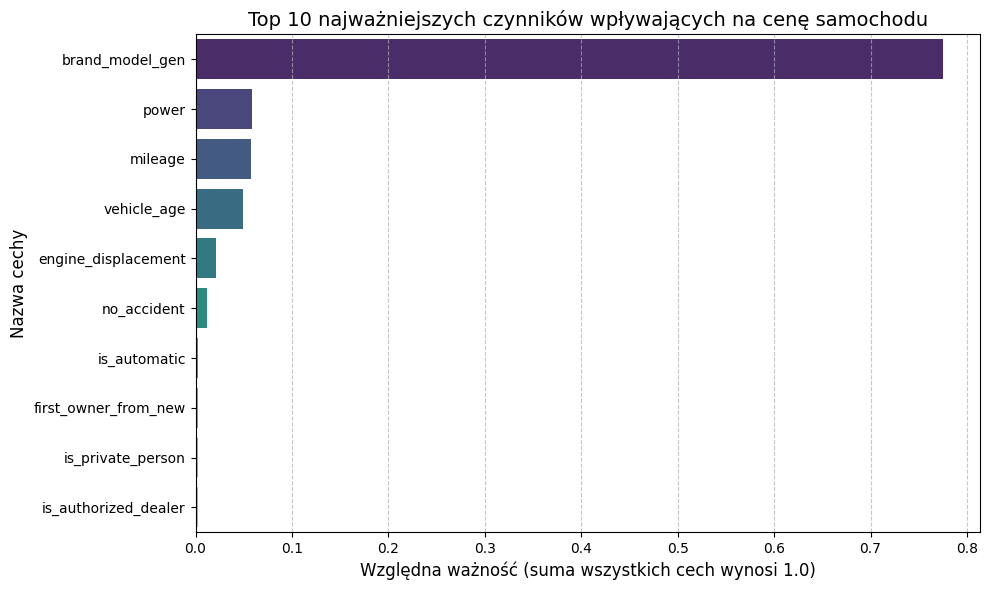

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_

feature_names = X_train.columns
feature_imp_df = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
})

feature_imp_df = feature_imp_df.sort_values(by='Ważność', ascending=False)

top_10_features = feature_imp_df.head(10)

print("Top 10 najważniejszych cech decydujących o wycenie:\n")
print(top_10_features.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Ważność', y='Cecha', data=top_10_features, palette='viridis')

plt.title('Top 10 najważniejszych czynników wpływających na cenę samochodu', fontsize=14)
plt.xlabel('Względna ważność ', fontsize=12)
plt.ylabel('Nazwa cechy', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download('/content/otomoto_powerbi_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>